In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from datetime import datetime
from sklearn.metrics import precision_score, recall_score, f1_score
import shap
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = r"C:\Users\sy.papadopoulos\OneDrive - Alumil S.A\Desktop\ml attrition data latest.csv"

try:
    df = pd.read_csv(file_path, encoding='ISO-8859-7', sep=';')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='cp1253', sep=';')
except pd.errors.ParserError as e:
    print("ParserError:", e)
    exit()

# Strip column names of extra whitespace
df.columns = df.columns.str.strip()

In [3]:
# Convert date columns to datetime
date_columns = ['Ημ/νία γέννησης', 'Ημ/νία πρόσληψης', 'Ημ/νία αποχώρησης']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%d/%m/%Y', errors='coerce', dayfirst=True)

# Create new features (Age, Tenure, Attrition)
today = datetime.today()
if 'Ημ/νία πρόσληψης' in df.columns:
    df['Tenure'] = (df['Ημ/νία αποχώρησης'].fillna(today) - df['Ημ/νία πρόσληψης']).dt.days // 365

if 'Ημ/νία αποχώρησης' in df.columns:
    df['Attrition'] = df['Ημ/νία αποχώρησης'].notnull().astype(int)

In [4]:
df.rename(columns={
    'Αριθμός μητρώου': 'Registry Number',
    'Φύλο': 'Gender',
    'Ηλικία': 'Age',
    'Ημ/νία πρόσληψης': 'Hire Date',
    'Ημ/νία αποχώρησης': 'Departure Date',
    'Περιγραφή Αιτ. Αποχώρησης': 'Departure Reason Description',
    'Ονομαστικός μισθός': 'Nominal Salary',
    'Σχέση Εργασίας': 'Work Relationship',
    'Περιγραφή Υποκαταστήματος': 'City',
    'Διεύθυνση': 'Division',
    'Ιδιότητα Προσωπικού': 'Job Property',
    'Θέση εργασίας': 'Job Position',
    'GRADE': 'Grade',
    'ΤΜΗΜΑ': 'Department'
}, inplace=True)

In [5]:
# Keep only indefinite-term contracts and voluntary departures
df = df[df['Work Relationship'] == 'ΑΟΡΙΣΤΟΥ ΧΡΟΝΟΥ']
df = df[(df['Departure Reason Description'] == 'VOLUNTARY DEPARTURE') | (df['Departure Reason Description'].isnull())]

# Update 'Attrition' column where 'Department' contains the word "ΕΠΑΝΑΤΙΜΟΛΟΓΗΣΗ"
df.loc[df['Department'].astype(str).str.contains('ΕΠΑΝΑΤΙΜΟΛΟΓΗΣΗ', na=False), 'Attrition'] = 0

# Convert Gender column values
df['Gender'] = df['Gender'].replace({1: 'Male', 2: 'Female'})

# Filter rows where 'Departure Date' is either greater than 2018-12-31 or is null
df = df[(df['Departure Date'] > '2018-12-31') | (df['Departure Date'].isnull())]

# Clean up Nominal Salary
df['Nominal Salary'] = df['Nominal Salary'].str.replace(',', '.', regex=False)
df['Nominal Salary'] = pd.to_numeric(df['Nominal Salary'], errors='coerce')
df['Nominal Salary'].fillna(df['Nominal Salary'].median(), inplace=True)

# Replace NaN values
df['Job Property'] = df['Job Property'].fillna('OPERATIONAL')

# Replace specific values in the 'Grade' column
df['Grade'] = df['Grade'].replace({
    '99999': '0.9',  # Replace '99999' with '0.9'
    '0,1': '0.99'    # Replace '0,1' with '0.99'
})
df['Grade'] = df['Grade'].astype(float)

# Store 'Registry Number' separately for mapping predictions later
registry_numbers = df['Registry Number']
df1 = df.copy()


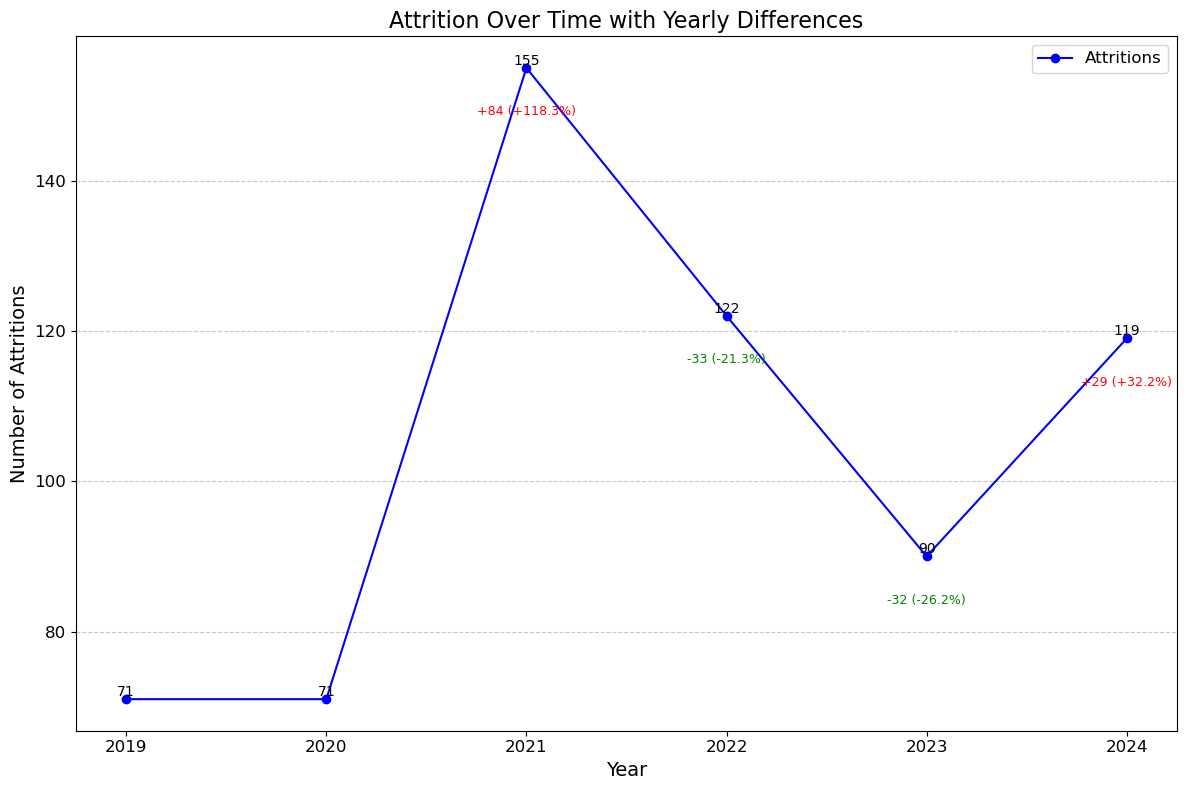

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

if 'Departure Date' in df1.columns:
    # Extract year from the 'Departure Date' column
    df1['Departure Year'] = df1['Departure Date'].dt.year

    # Group by year and sum attrition counts
    attrition_over_time = df1.groupby('Departure Year')['Attrition'].sum()

    # Calculate year-over-year differences
    attrition_diff = attrition_over_time.diff().fillna(0).astype(int)
    attrition_pct_change = attrition_over_time.pct_change().fillna(0) * 100

    # Plot
    plt.figure(figsize=(12, 8))
    plt.plot(attrition_over_time.index, attrition_over_time.values, marker='o', linestyle='-', color='b', label="Attritions")

    # Add data labels for each year
    for year, count, diff, pct in zip(attrition_over_time.index, attrition_over_time.values, attrition_diff.values, attrition_pct_change.values):
        # Display the attrition count
        plt.text(year, count, f'{count}', ha='center', va='bottom', fontsize=10, color='black')
        
        # Display the difference (units and percentage) with color based on positive/negative variance
        if diff != 0:
            diff_text = f"{diff:+d} ({pct:+.1f}%)"
            color = 'green' if diff < 0 else 'red'
            plt.text(year, count - 5, diff_text, ha='center', va='top', fontsize=9, color=color)

    # Customize the plot
    plt.title("Attrition Over Time with Yearly Differences", fontsize=16)
    plt.xlabel("Year", fontsize=14)
    plt.ylabel("Number of Attritions", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


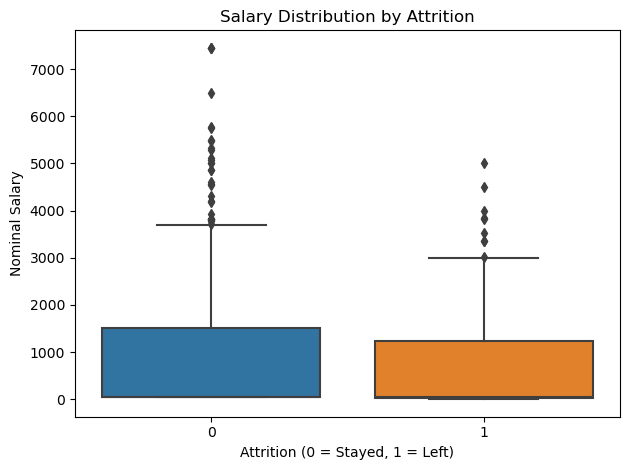

In [7]:
sns.boxplot(x='Attrition', y='Nominal Salary', data=df)
plt.title("Salary Distribution by Attrition")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Nominal Salary")
plt.tight_layout()
plt.show()


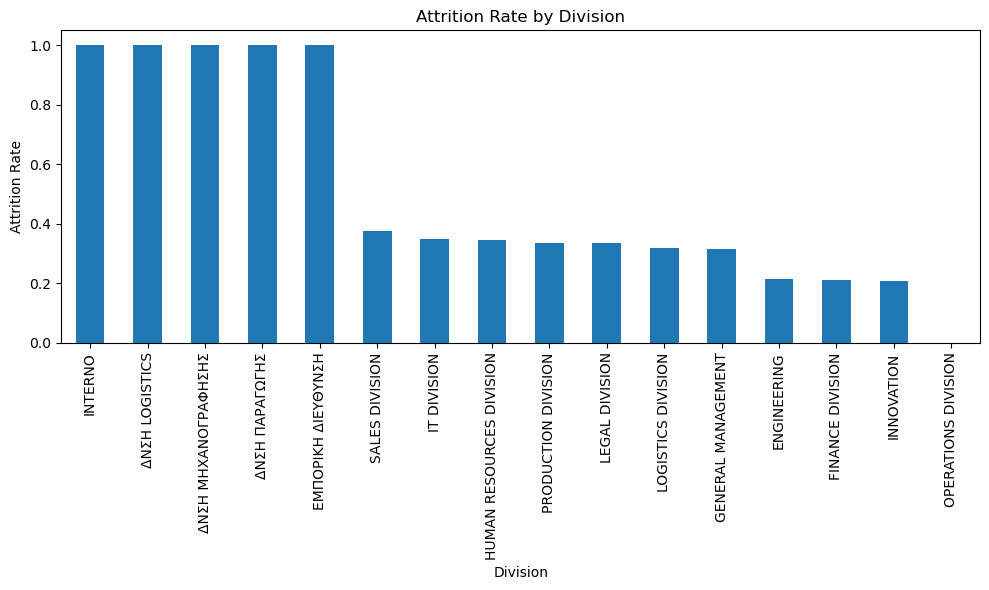

In [8]:
attrition_by_division = df.groupby('Division')['Attrition'].mean().sort_values(ascending=False)

# Plot
attrition_by_division.plot(kind='bar', figsize=(10, 6), title="Attrition Rate by Division")
plt.ylabel("Attrition Rate")
plt.xlabel("Division")
plt.tight_layout()
plt.show()


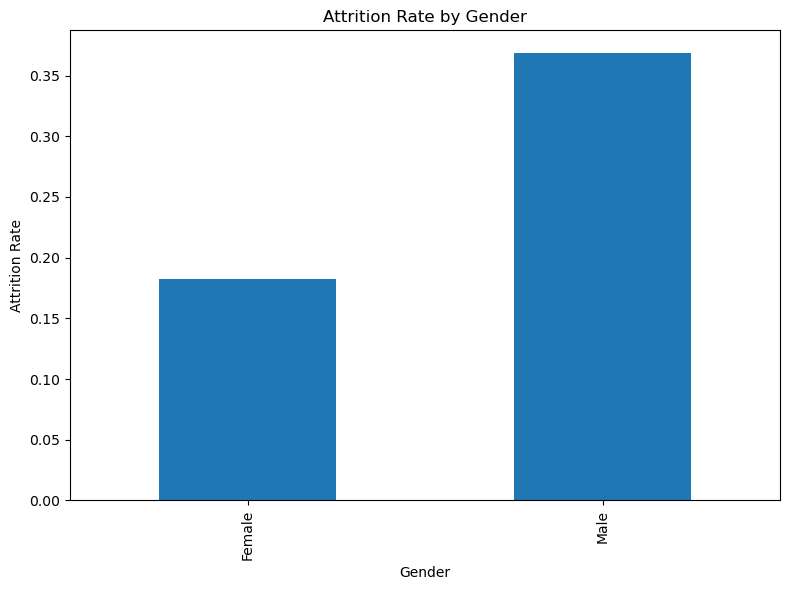

In [9]:
attrition_by_gender = df.groupby('Gender')['Attrition'].mean()

# Plot
attrition_by_gender.plot(kind='bar', figsize=(8, 6), title="Attrition Rate by Gender")
plt.ylabel("Attrition Rate")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()


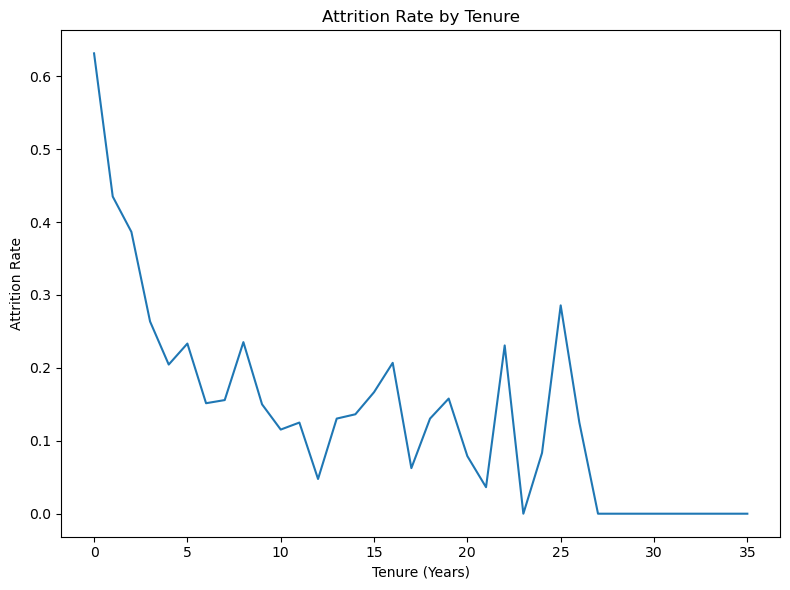

In [10]:
attrition_by_tenure = df.groupby('Tenure')['Attrition'].mean()

# Plot
attrition_by_tenure.plot(kind='line', figsize=(8, 6), title="Attrition Rate by Tenure")
plt.ylabel("Attrition Rate")
plt.xlabel("Tenure (Years)")
plt.tight_layout()
plt.show()


In [11]:

# Drop unnecessary columns
df.drop(columns=['Departure Date', 'Hire Date', 'Work Relationship', 'Registry Number', 'Departure Reason Description'], inplace=True)

# Convert categorical columns to dummies
categorical_columns = ['Gender', 'City', 'Division', 'Job Property', 'Job Position', 'Department']
df_transformed = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [12]:
X = df_transformed.drop(columns=['Attrition'])
y = df_transformed['Attrition']

object_cols = X.select_dtypes(include=['object']).columns
print("Object columns in X:", object_cols)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Object columns in X: Index([], dtype='object')


In [13]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weight_dict = dict(enumerate(class_weights))

In [14]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0.01, 0.1],
    'reg_lambda': [0.01, 0.1]
}

xgb = XGBClassifier(scale_pos_weight=class_weights[1] / class_weights[0], random_state=42)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=kf, scoring='roc_auc', verbose=1, n_jobs=-1)
grid_search.fit(X_scaled, y)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_typ...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'reg_alpha': [0.01, 0.1], 'reg_lambda': [0.01, 0.1],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring='roc_auc', verbose=1)

In [15]:
best_xgb = grid_search.best_estimator_
y_proba = best_xgb.predict_proba(X_scaled)[:, 1]
y_pred = best_xgb.predict(X_scaled)

# Combine predictions with 'Registry Number'
results = pd.DataFrame({
    'Registry Number': registry_numbers,
    'Attrition_Probability': y_proba,
    'Predicted_Attrition': y_pred
})

# Calculate total predicted attrition
total_predicted_attrition = results['Predicted_Attrition'].sum()
print(f"Total Predicted Attrition: {total_predicted_attrition}")

# View employees likely to leave
likely_to_leave = results[results['Predicted_Attrition'] == 1]
print("Employees Likely to Leave:")
print(likely_to_leave)

Total Predicted Attrition: 643
Employees Likely to Leave:
      Registry Number  Attrition_Probability  Predicted_Attrition
14            1010129               0.894110                    1
72            1010339               0.634254                    1
98            1010477               0.862236                    1
153           1010681               0.827883                    1
155           1010683               0.577113                    1
...               ...                    ...                  ...
3642          1017287               0.712654                    1
3643          1017288               0.808388                    1
3644          1018277               0.714795                    1
3666          1018312               0.611304                    1
3683          1017187               0.751195                    1

[643 rows x 3 columns]


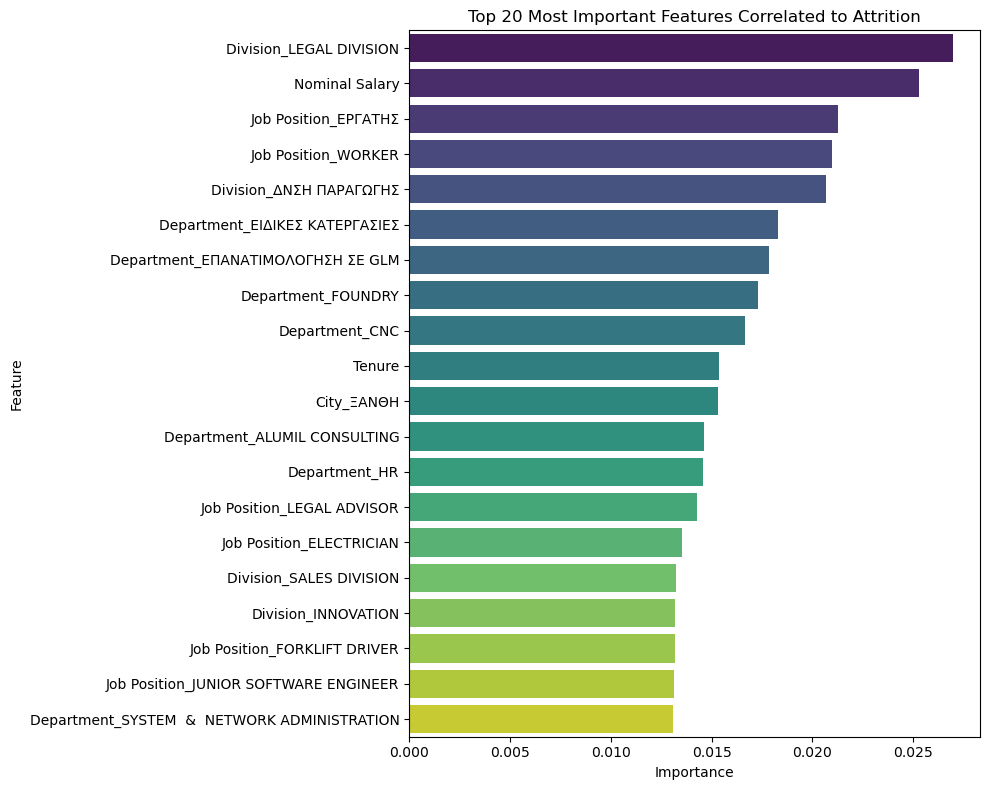

In [16]:
# Retrieve feature importances from the XGBoost model
feature_importances = best_xgb.feature_importances_

# Create a dataframe to hold feature names and importance
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort by importance descending, then slice top 20
top_20_features = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

# Plot the top 20 features as a bar chart
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_20_features,
    palette='viridis'
)
plt.title('Top 20 Most Important Features Correlated to Attrition')
plt.tight_layout()
plt.show()

In [17]:
# Step 1: Filter active employees (Departure Date is null)
active_employees = df[df['Attrition'] == 0]  # Attrition == 0 means still active
active_employees['Registry Number'] = registry_numbers[df['Attrition'] == 0]  # Add Registry Number back

# Step 2: Ensure consistent features with the trained model
active_employees_transformed = pd.get_dummies(active_employees, columns=categorical_columns, drop_first=True)

# Add missing columns (from training data) as 0 to maintain consistency
missing_cols = set(X.columns) - set(active_employees_transformed.columns)
for col in missing_cols:
    active_employees_transformed[col] = 0

# Reorder columns to match the training data
active_employees_transformed = active_employees_transformed[X.columns]

# Step 3: Scale the features using the same scaler
active_employees_scaled = scaler.transform(active_employees_transformed)

# Step 4: Predict attrition for next year
active_employees['Attrition_Probability'] = best_xgb.predict_proba(active_employees_scaled)[:, 1]
active_employees['Predicted_Attrition'] = best_xgb.predict(active_employees_scaled)

# Step 5: Filter employees likely to attrite
likely_to_attrite_next_year = active_employees[active_employees['Predicted_Attrition'] == 1]

# Display the number of employees predicted to attrite
num_likely_to_attrite = len(likely_to_attrite_next_year)
print(f"Number of employees predicted to attrite next year: {num_likely_to_attrite}")

# Display employees likely to attrite
print("Employees Likely to Attrite Next Year:")
print(likely_to_attrite_next_year[['Registry Number', 'Attrition_Probability', 'Predicted_Attrition']])




Number of employees predicted to attrite next year: 53
Employees Likely to Attrite Next Year:
      Registry Number  Attrition_Probability  Predicted_Attrition
1085          1015791               0.552526                    1
1767          1016852               0.542219                    1
2456          1016883               0.581750                    1
2465          1017586               0.801195                    1
2466          1017619               0.581750                    1
2701          1017624               0.707468                    1
2702          1017651               0.676516                    1
2755          1015920               0.517581                    1
2776          1016717               0.559650                    1
2785          1017179               0.570882                    1
2789          1017558               0.507739                    1
2790          1017565               0.675790                    1
2800          1017676               0.507739    

C:\Users\sy.papadopoulos\AppData\Local\Temp\ipykernel_1312\2027232839.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_employees['Registry Number'] = registry_numbers[df['Attrition'] == 0]  # Add Registry Number back
C:\Users\sy.papadopoulos\AppData\Local\Temp\ipykernel_1312\2027232839.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_employees['Attrition_Probability'] = best_xgb.predict_proba(active_employees_scaled)[:, 1]
C:\Users\sy.papadopoulos\AppData\Local\Temp\ipykernel_1312\20272

In [18]:
# Optional: Group by Division or Department to analyze
attrition_by_division = likely_to_attrite_next_year.groupby('Division')['Predicted_Attrition'].sum().sort_values(ascending=False)

print("Predicted Attrition by Division:")
print(attrition_by_division)

# Print the Registry Numbers of employees likely to attrite by Division
print("\nRegistry Numbers of employees likely to attrite by Division:")

attrition_by_division_list = likely_to_attrite_next_year.groupby('Division')['Registry Number'].apply(list)

for division_name, reg_list in attrition_by_division_list.items():
    print(f"\nDivision: {division_name}")
    for reg in reg_list:
        print(f"   Registry Number: {reg}")

Predicted Attrition by Division:
Division
PRODUCTION DIVISION         22
SALES DIVISION              14
LOGISTICS DIVISION           4
ENGINEERING                  3
IT DIVISION                  3
GENERAL MANAGEMENT           2
HUMAN RESOURCES DIVISION     2
INNOVATION                   2
FINANCE DIVISION             1
Name: Predicted_Attrition, dtype: int32

Registry Numbers of employees likely to attrite by Division:

Division: ENGINEERING
   Registry Number: 1017191
   Registry Number: 1017259
   Registry Number: 1017640

Division: FINANCE DIVISION
   Registry Number: 1017291

Division: GENERAL MANAGEMENT
   Registry Number: 1015791
   Registry Number: 1017163

Division: HUMAN RESOURCES DIVISION
   Registry Number: 1016852
   Registry Number: 1017689

Division: INNOVATION
   Registry Number: 1017615
   Registry Number: 1016609

Division: IT DIVISION
   Registry Number: 1017336
   Registry Number: 1017353
   Registry Number: 1017459

Division: LOGISTICS DIVISION
   Registry Number: 1

Precision: 0.92
Recall: 0.94
F1 Score: 0.93
Historical Attrition Rate: 33.30%
Predicted Attrition Rate: 4.21%
Confusion Matrix:
True Negatives: 1205
False Positives: 53
False Negatives: 38
True Positives: 590


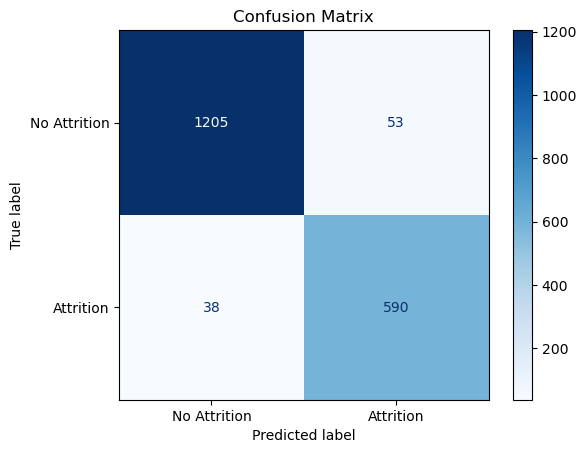

In [19]:
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

historical_attrition_rate = df['Attrition'].mean()
predicted_attrition_rate = likely_to_attrite_next_year.shape[0] / active_employees.shape[0]

print(f"Historical Attrition Rate: {historical_attrition_rate:.2%}")
print(f"Predicted Attrition Rate: {predicted_attrition_rate:.2%}")

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
tn, fp, fn, tp = cm.ravel()  # True Negatives, False Positives, False Negatives, True Positives
print(f"Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

# Visualize the confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Attrition", "Attrition"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

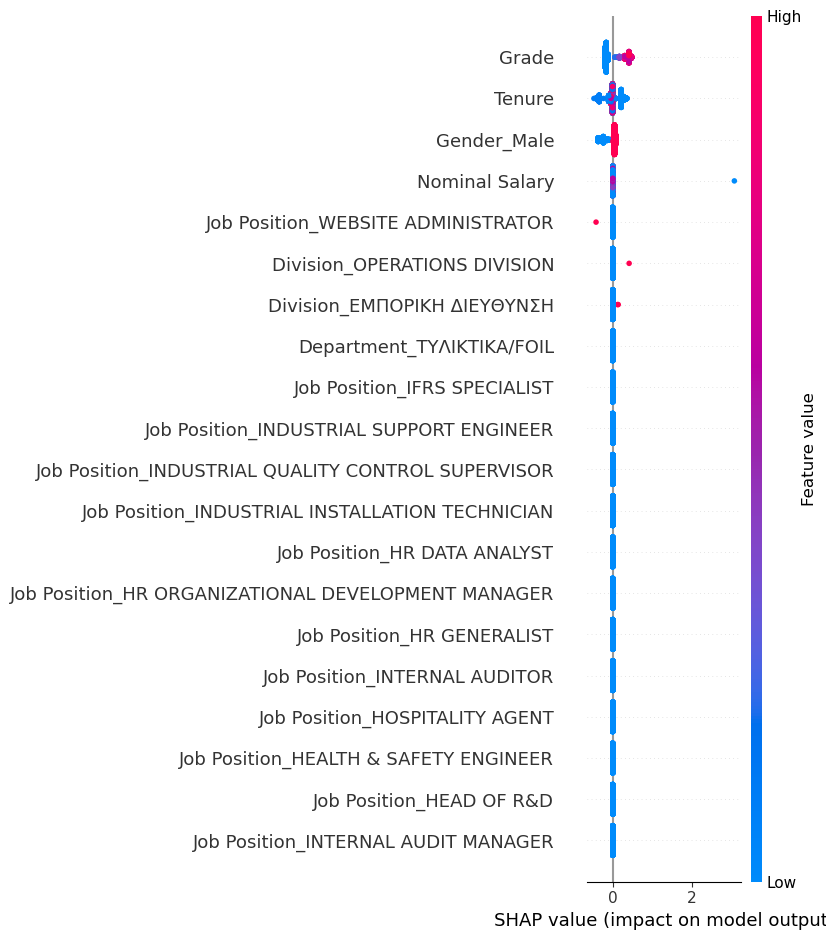

In [20]:
# Verify and fix column consistency
for col in set(df_transformed.columns) - set(X.columns):
    X[col] = 0
X = X[df_transformed.columns]

# Ensure all columns are numeric and fill missing values
X.fillna(0, inplace=True)
X = X.astype(float)

# Initialize SHAP
explainer = shap.Explainer(best_xgb, X)
shap_values = explainer(X)

# Plot SHAP summary
shap.summary_plot(shap_values, X)